# Research QuantBook: ML-Enhanced Pairs Trading

## Objectif
Analyser une strategie de pairs trading amelioree par Machine Learning.

## Strategie
- **Univers**: Paires d instruments disponibles en Docker (SPY/TLT, XLF/XLE, AAPL/MSFT, GOOGL/GLD, MSFT/GOOGL)
- **Selection**: Test de cointegration Engle-Granger
- **ML**: RandomForest pour predire le timing d entree
- **Features**: Z-score, demi-vie, regime de volatilite, momentum
- **Entree**: |Z| > 2 + prediction ML positive
- **Sortie**: |Z| < 0.5

## Performance de reference
Sharpe ~1.2-1.8 (2020-2025) - pairs trading avec filtrage ML.

## Hypotheses a tester
1. Seuil Z-score: 1.5, 2.0, 2.5
2. Demi-vie max: 30, 60, 90 jours
3. ML threshold: 0.3, 0.5, 0.7

## Prerequis
- Environnement Lean Research
- statsmodels pour cointegration
- scikit-learn pour ML
- Duree estimee: ~15 minutes

## Note
Cette strategie combine l analyse statistique (cointegration) avec le ML pour optimiser le timing d entree.
Utilise les tickers disponibles dans le Docker quantconnect/research:latest.

In [1]:
# Setup QuantBook
from AlgorithmImports import *
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 5)

qb = QuantBook()
print("QuantBook initialisé.")

QuantBook initialisé.


## 1. Chargement des donnees

On charge les donnees d instruments disponibles en Docker pour la periode 2020-2026.

In [2]:
# Paires d instruments disponibles en Docker
# Docker quantconnect/research:latest fournit uniquement:
# AAPL, MSFT, GOOGL (tech stocks), SPY (S&P 500), TLT (treasuries),
# GLD (gold), XLF (financials), XLE (energy)
etf_pairs = [
    ("SPY", "IWM"),    # S&P 500 vs Treasuries (risk-on/off)
    ("BAC", "USO"),    # Financials vs Energy (sector)
    ("AAPL", "QQQ"),  # Apple vs Microsoft (tech rivals)
    ("GOOGL", "USO"),  # Alphabet vs Gold (growth vs safe haven)
    ("QQQ", "GOOGL"), # Microsoft vs Alphabet (tech pair)
]

symbols = {}
for ticker1, ticker2 in etf_pairs:
    symbols[ticker1] = qb.add_equity(ticker1, Resolution.DAILY).symbol
    symbols[ticker2] = qb.add_equity(ticker2, Resolution.DAILY).symbol

# Charger l historique (2020-2026)
start = datetime(2020, 1, 1)
end = datetime(2026, 1, 1)

history = qb.history(list(symbols.values()), start, end, Resolution.DAILY)
print(f"Donnees chargees: {len(history)} lignes")
print(f"Instruments: {list(symbols.keys())}")

Donnees chargees: 10556 lignes
Instruments: ['SPY', 'IWM', 'BAC', 'USO', 'AAPL', 'QQQ', 'GOOGL']


Pivot de la serie close en DataFrame large, avec remapping des colonnes Symbol ticker pour ML-EnhancedPairs.

In [3]:
# Pivoter les données
closes = history['close'].unstack(level=0)

symbol_to_ticker = {str(v): k for k, v in symbols.items()}
closes.columns = [symbol_to_ticker.get(str(c), str(c)) for c in closes.columns]
closes = closes.dropna()

print(f"Période: {(closes.index[0][-1] if isinstance(closes.index[0], tuple) else closes.index[0]).date()} à {(closes.index[-1][-1] if isinstance(closes.index[-1], tuple) else closes.index[-1]).date()}")
print(f"Données: {len(closes)} jours de trading")
print(f"ETFs: {list(closes.columns)}")
print(f"\nStatistiques des prix finaux:")
for ticker in closes.columns:
    ret = (closes[ticker].iloc[-1] / closes[ticker].iloc[0] - 1) * 100
    print(f"  {ticker}: {ret:+.1f}%")

Période: 2020-01-02 à 2025-12-31
Données: 1508 jours de trading
ETFs: ['AAPL', 'BAC', 'GOOGL', 'IWM', 'QQQ', 'SPY', 'USO']

Statistiques des prix finaux:
  AAPL: +64.3%
  BAC: +12.0%
  GOOGL: +50.7%
  IWM: +35.4%
  QQQ: +48.9%
  SPY: +24.7%
  USO: -60.5%


## 2. Test de Cointégration

Le test d'Engle-Granger vérifie si deux séries ont une relation à long terme.

In [4]:
def engle_granger_coint(y1, y2, significance=0.05):
    """
    Test de cointégration Engle-Granger.
    
    Retourne: (is_cointegrated, hedge_ratio, half_life, spread)
    """
    df = pd.DataFrame({'y': y1, 'x': y2}).dropna()
    
    if len(df) < 30:
        return False, None, None, None
    
    # OLS pour le hedge ratio
    x = sm.add_constant(df['x'])
    result = sm.OLS(df['y'], x).fit()
    hedge_ratio = result.params['x']
    
    # Calcul du spread
    spread = df['y'] - hedge_ratio * df['x']
    
    # Test ADF sur le spread
    adf_result = adfuller(spread.dropna())
    p_value = adf_result[1]
    
    is_cointegrated = p_value < significance
    
    # Demi-vie
    df_spread = pd.DataFrame({'spread': spread}).dropna()
    df_spread['spread_lag'] = df_spread['spread'].shift(1)
    df_spread = df_spread.dropna()
    
    if len(df_spread) < 10:
        half_life = 999
    else:
        from sklearn.linear_model import LinearRegression
        model = LinearRegression()
        model.fit(df_spread[['spread_lag']], df_spread['spread'])
        lambda_coef = model.coef_[0]
        
        if lambda_coef >= 1:
            half_life = 999
        else:
            half_life = max(0, -np.log(2) / np.log(lambda_coef))
    
    return is_cointegrated, hedge_ratio, half_life, spread

# Tester toutes les paires
print("=== Test de Cointégration ===")
print(f"{'Paire':<15} {'Cointégré?':<12} {'Hedge Ratio':>12} {'Demi-vie':>10}")
print("-" * 52)

cointegrated_pairs = []
for ticker1, ticker2 in etf_pairs:
    is_coint, hr, hl, spread = engle_granger_coint(closes[ticker1], closes[ticker2])
    status = "OUI" if is_coint else "NON"
    hr_str = f"{hr:.3f}" if hr else "N/A"
    hl_str = f"{hl:.1f}j" if hl else "N/A"
    print(f"{ticker1}/{ticker2:<10} {status:<12} {hr_str:>12} {hl_str:>10}")
    
    if is_coint and hl and 5 < hl < 60:
        cointegrated_pairs.append((ticker1, ticker2, hr, hl, spread))

print(f"\nPaires cointégrées avec demi-vie valide: {len(cointegrated_pairs)}")

=== Test de Cointégration ===
Paire           Cointégré?    Hedge Ratio   Demi-vie
----------------------------------------------------
SPY/IWM        OUI                 1.142      20.7j


BAC/USO        NON                 0.125     196.2j
AAPL/QQQ        OUI                 0.442      40.4j


GOOGL/USO        NON                -1.158     172.6j
QQQ/GOOGL      OUI                 0.126      55.9j

Paires cointégrées avec demi-vie valide: 3


### Interprétation: Cointégration

- **Cointégré**: Les deux prix ont une relation stable à long terme
- **Hedge Ratio**: Combien de l'asset 2 pour couvrir l'asset 1
- **Demi-vie**: Temps de retour à la moyenne (court = meilleur)
- **Spread**: Écart normalisé à mean-revert

## 3. Calcul du Z-Score

Le Z-score indique combien d'écarts-types le spread est de sa moyenne.

In [5]:
def calculate_zscore(spread, window=20):
    """Calcule le Z-score du spread."""
    mean = spread.rolling(window).mean()
    std = spread.rolling(window).std()
    return (spread - mean) / std

# Exemple: première paire cointégrée
if cointegrated_pairs:
    ticker1, ticker2, hr, hl, spread = cointegrated_pairs[0]
    zscore = calculate_zscore(spread)
    
    print(f"Exemple: Paire {ticker1}/{ticker2}")
    print(f"Hedge Ratio: {hr:.3f}")
    print(f"Demi-vie: {hl:.1f} jours")
    print(f"\nZ-score - 10 derniers jours:")
    print(zscore.iloc[-10:])

Exemple: Paire SPY/IWM
Hedge Ratio: 1.142
Demi-vie: 20.7 jours

Z-score - 10 derniers jours:
time
2025-12-17 16:00:00   NaN
2025-12-18 16:00:00   NaN
2025-12-19 16:00:00   NaN
2025-12-22 16:00:00   NaN
2025-12-23 16:00:00   NaN
2025-12-24 13:00:00   NaN
2025-12-26 16:00:00   NaN
2025-12-29 16:00:00   NaN
2025-12-30 16:00:00   NaN
2025-12-31 16:00:00   NaN
dtype: float64


## 4. Feature Engineering pour ML

Création des features pour le modèle de prédiction d'entrée.

In [6]:
def create_ml_features(spread, zscore):
    """Crée les features ML."""
    features = pd.DataFrame(index=spread.index)
    
    # Z-score actuel
    features['ZScore'] = zscore
    
    # Demi-vie (récurrente)
    df_spread = pd.DataFrame({'spread': spread}).dropna()
    df_spread['spread_lag'] = df_spread['spread'].shift(1)
    df_spread = df_spread.dropna()
    
    from sklearn.linear_model import LinearRegression
    half_lives = []
    for i in range(50, len(df_spread)):
        temp_df = df_spread.iloc[max(0, i-60):i]
        if len(temp_df) > 10:
            model = LinearRegression()
            model.fit(temp_df[['spread_lag']], temp_df['spread'])
            lam = model.coef_[0]
            if lam < 1:
                hl = max(0, -np.log(2) / np.log(lam))
                half_lives.append(hl)
            else:
                half_lives.append(999)
        else:
            half_lives.append(999)
    
    # Aligner avec l'index
    half_life_series = pd.Series([999] * len(features), index=features.index)
    for i, idx in enumerate(features.index):
        if i < len(half_lives):
            half_life_series.iloc[i] = half_lives[i]
    
    features['HalfLife'] = half_life_series
    
    # Régime de volatilité
    vol = spread.pct_change().rolling(20).std()
    vol_long = spread.pct_change().rolling(60).std()
    features['VolRegime'] = (vol > vol_long).astype(int)
    
    # Momentum du spread
    features['Momentum'] = spread.pct_change(5)
    
    # Label: bonne entrée si |Z| > 2
    features['Label'] = (np.abs(zscore) > 2.0).astype(int)
    
    return features.dropna()

# Exemple
if cointegrated_pairs:
    ticker1, ticker2, hr, hl, spread = cointegrated_pairs[0]
    zscore = calculate_zscore(spread)
    features = create_ml_features(spread, zscore)
    
    print(f"Features ML - {ticker1}/{ticker2}:")
    print(f"Total échantillons: {len(features)}")
    print(f"\nDistribution des labels:")
    print(features['Label'].value_counts())
    print(f"\nDerniers 5 jours:")
    print(features.iloc[-5:])

Features ML - SPY/IWM:
Total échantillons: 313

Distribution des labels:
Label
0    281
1     32
Name: count, dtype: int64

Derniers 5 jours:
                       ZScore  HalfLife  VolRegime  Momentum  Label
time                                                               
2021-04-21 16:00:00 -0.261234       0.0          0       0.0      0
2021-04-22 16:00:00 -0.210977       0.0          0       0.0      0
2021-04-23 16:00:00 -0.275900       0.0          0       0.0      0
2021-04-26 16:00:00 -0.274981       0.0          0       0.0      0
2021-04-27 16:00:00 -0.223607       0.0          0       0.0      0


## 5. Entraînement du modèle ML

RandomForest pour prédire les opportunités d'entrée.

In [7]:
def prepare_all_features(closes, cointegrated_pairs):
    """Prépare les features pour toutes les paires."""
    all_features = []
    
    for ticker1, ticker2, hr, hl, spread in cointegrated_pairs:
        zscore = calculate_zscore(spread)
        features = create_ml_features(spread, zscore)
        if len(features) > 20:
            all_features.append(features)
    
    if not all_features:
        return None, None
    
    combined = pd.concat(all_features, ignore_index=True)
    X = combined.drop('Label', axis=1)
    y = combined['Label']
    
    return X.fillna(0), y.fillna(0)

# Préparer les données
X, y = prepare_all_features(closes, cointegrated_pairs)

if X is not None:
    # Split train/test
    split_idx = int(len(X) * 0.8)
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
    
    # StandardScaler
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Entraînement
    model = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42)
    model.fit(X_train_scaled, y_train)
    
    # Évaluation
    train_acc = model.score(X_train_scaled, y_train)
    test_acc = model.score(X_test_scaled, y_test)
    
    print("=== Performance ML ===")
    print(f"Train Accuracy: {train_acc:.3f}")
    print(f"Test Accuracy:  {test_acc:.3f}")
    print(f"\nFeature Importance:")
    for feat, imp in zip(X.columns, model.feature_importances_):
        print(f"  {feat}: {imp:.3f}")

=== Performance ML ===
Train Accuracy: 1.000
Test Accuracy:  1.000

Feature Importance:
  ZScore: 0.911
  HalfLife: 0.023
  VolRegime: 0.004
  Momentum: 0.063


### Interprétation: Modèle ML

- **Accuracy**: Pourcentage de prédictions correctes
- **Feature Importance**: Quelle feature influence le plus
- **Z-Score**: Généralement le plus important pour les pairs
- **Demi-vie**: Filtre les pairs qui mean-revert trop lentement

## 6. Backtest ML-Enhanced Pairs

Simulation avec filtrage ML des opportunités d'entrée.

In [8]:
def backtest_ml_pairs(closes, cointegrated_pairs,
                      z_entry=2.0,
                      z_exit=0.5,
                      ml_threshold=0.5,
                      max_pairs=3):
    """
    Backtest ML-Enhanced Pairs.
    """
    if not cointegrated_pairs:
        return None
    
    # Entraîner le modèle
    X, y = prepare_all_features(closes, cointegrated_pairs)
    if X is None:
        return None
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    model = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42)
    model.fit(X_scaled, y)
    
    portfolio_values = [1.0]
    positions = {}  # (ticker1, ticker2) -> (type, entry_z, entry_date)
    
    warmup = 70
    
    for i in range(warmup, len(closes)):
        current_date = closes.index[i]
        
        # Check exits
        for pair_key in list(positions.keys()):
            pos_type, entry_z, entry_idx = positions[pair_key]
            ticker1, ticker2 = pair_key
            
            # Recalculer Z-score
            is_coint, hr, hl, spread = engle_granger_coint(
                closes[ticker1].iloc[:i+1],
                closes[ticker2].iloc[:i+1]
            )
            
            if spread is None:
                continue
            
            current_z = calculate_zscore(spread).iloc[-1]
            
            # Exit condition
            if abs(current_z) < z_exit:
                del positions[pair_key]
        
        # Find new opportunities
        opportunities = []
        
        for ticker1, ticker2, hr, hl, spread in cointegrated_pairs:
            if (ticker1, ticker2) in positions:
                continue  # Already in position
            
            # Recalculer spread et Z-score
            is_coint, hr_new, hl_new, spread_new = engle_granger_coint(
                closes[ticker1].iloc[:i+1],
                closes[ticker2].iloc[:i+1]
            )
            
            if spread_new is None:
                continue
            
            zscore = calculate_zscore(spread_new)
            current_z = zscore.iloc[-1]
            
            if abs(current_z) < z_entry:
                continue
            
            # ML prediction
            vol_regime = (spread_new.pct_change().rolling(20).std().iloc[-1] >
                         spread_new.pct_change().rolling(60).std().mean())
            momentum = spread_new.pct_change(5).iloc[-1]
            
            features = [[current_z, hl_new, int(vol_regime), momentum]]
            features_scaled = scaler.transform(features)
            ml_proba = model.predict_proba(features_scaled)[0][1]
            
            if ml_proba < ml_threshold:
                continue
            
            # Score combine ML et Z magnitude
            score = ml_proba * abs(current_z)
            opportunities.append((ticker1, ticker2, current_z, score, hl_new))
        
        # Select top opportunities
        opportunities.sort(key=lambda x: x[3], reverse=True)
        
        for ticker1, ticker2, z, score, hl in opportunities[:max_pairs]:
            if len(positions) >= max_pairs:
                break
            positions[(ticker1, ticker2)] = ('long_spread' if z < 0 else 'short_spread', z, i)
        
        # Calculate returns
        if i < len(closes) - 1:
            daily_returns = closes.iloc[i+1] / closes.iloc[i] - 1
            port_return = 0
            
            for (ticker1, ticker2), (pos_type, entry_z, entry_idx) in positions.items():
                if pos_type == 'short_spread':
                    # Short ticker1, Long ticker2
                    port_return += 0.45 * (-daily_returns[ticker1] + daily_returns[ticker2])
                else:
                    # Long ticker1, Short ticker2
                    port_return += 0.45 * (daily_returns[ticker1] - daily_returns[ticker2])
            
            portfolio_values.append(portfolio_values[-1] * (1 + port_return))
        else:
            portfolio_values.append(portfolio_values[-1])
    
    # Métriques
    returns = np.diff(portfolio_values) / np.array(portfolio_values[:-1])
    cum_returns = pd.Series(portfolio_values, index=closes.index[warmup-1:])
    
    total_ret = (portfolio_values[-1] / portfolio_values[0]) - 1
    years = len(returns) / 252
    cagr = (1 + total_ret) ** (1 / years) - 1 if years > 0 else 0
    vol = np.std(returns) * np.sqrt(252) if len(returns) > 1 else 0
    sharpe = (cagr - 0.03) / vol if vol > 0.001 else 0
    
    running_max = cum_returns.expanding().max()
    drawdown = (cum_returns - running_max) / running_max
    max_dd = drawdown.min()
    
    return {
        'cum': cum_returns,
        'sharpe': sharpe,
        'cagr': cagr,
        'max_dd': max_dd,
        'vol': vol,
        'final_value': portfolio_values[-1]
    }

result = backtest_ml_pairs(closes, cointegrated_pairs)
if result:
    print(f"Performance ML-Enhanced Pairs:")
    print(f"  Sharpe: {result['sharpe']:.3f}")
    print(f"  CAGR:   {result['cagr']:.1%}")
    print(f"  Max DD: {result['max_dd']:.1%}")
    print(f"  Vol:    {result['vol']:.1%}")
else:
    print("Pas de paires cointégrées trouvées.")

Performance ML-Enhanced Pairs:
  Sharpe: -1.060
  CAGR:   -1.0%
  Max DD: -8.1%
  Vol:    3.8%


## 7. Test du seuil Z-score

In [9]:
# Test différents seuils Z
z_values = [1.5, 2.0, 2.5]

print(f"{'Z Entry':<10} {'Sharpe':>8} {'CAGR':>8} {'MaxDD':>8}")
print("-" * 38)

z_results = {}
for z in z_values:
    r = backtest_ml_pairs(closes, cointegrated_pairs, z_entry=z)
    if r:
        z_results[f"{z}"] = r
        print(f"{z}{'':<9} {r['sharpe']:>8.3f} {r['cagr']:>7.1%} {r['max_dd']:>7.1%}")

if z_results:
    best_z = max(z_results.items(), key=lambda x: x[1]['sharpe'])
    print(f"\nMeilleur Z Entry: {best_z[0]} (Sharpe={best_z[1]['sharpe']:.3f}")

Z Entry      Sharpe     CAGR    MaxDD
--------------------------------------


1.5            -1.060   -1.0%   -8.1%


2.0            -1.060   -1.0%   -8.1%


2.5            -1.482   -1.8%  -12.9%

Meilleur Z Entry: 1.5 (Sharpe=-1.060


## 8. Test du seuil ML

In [10]:
# Test différents seuils ML
ml_values = [0.3, 0.5, 0.7]

print(f"{'ML Threshold':<15} {'Sharpe':>8} {'CAGR':>8} {'MaxDD':>8}")
print("-" * 42)

ml_results = {}
for thresh in ml_values:
    r = backtest_ml_pairs(closes, cointegrated_pairs, ml_threshold=thresh)
    if r:
        ml_results[f"{thresh}"] = r
        print(f"{thresh}{'':<14} {r['sharpe']:>8.3f} {r['cagr']:>7.1%} {r['max_dd']:>7.1%}")

if ml_results:
    best_ml = max(ml_results.items(), key=lambda x: x[1]['sharpe'])
    print(f"\nMeilleur ML Threshold: {best_ml[0]} (Sharpe={best_ml[1]['sharpe']:.3f}")

ML Threshold      Sharpe     CAGR    MaxDD
------------------------------------------


0.3                 -1.060   -1.0%   -8.1%


0.5                 -1.060   -1.0%   -8.1%


0.7                 -1.060   -1.0%   -8.1%

Meilleur ML Threshold: 0.3 (Sharpe=-1.060


## 9. Comparaison avec SPY B&H

In [11]:
if result:
    # Charger SPY pour comparaison
    spy = qb.add_equity("SPY", Resolution.DAILY).symbol
    spy_history = qb.history(spy, start, end, Resolution.DAILY)
    spy_close = spy_history['close']
    
    # Aligner les dates
    warmup = 70
    spy_values = spy_close.iloc[warmup:] / spy_close.iloc[warmup]
    
    # Métriques SPY
    spy_ret = spy_values.pct_change().dropna()
    spy_cagr = (spy_values.iloc[-1] ** (252/len(spy_values))) - 1
    spy_vol = spy_ret.std() * np.sqrt(252)
    spy_sharpe = (spy_cagr - 0.03) / spy_vol
    spy_dd = (spy_values / spy_values.cummax() - 1).min()
    
    print("=== Comparaison vs SPY B&H ===")
    print(f"{'Stratégie':<20} {'CAGR':>10} {'Sharpe':>10} {'MaxDD':>10}")
    print("-" * 53)
    print(f"{'ML-Enhanced Pairs':<20} {result['cagr']:>9.1%} {result['sharpe']:>10.3f} {result['max_dd']:>9.1%}")
    print(f"{'SPY B&H':<20} {spy_cagr:>9.1%} {spy_sharpe:>10.3f} {spy_dd:>9.1%}")

=== Comparaison vs SPY B&H ===
Stratégie                  CAGR     Sharpe      MaxDD
-----------------------------------------------------
ML-Enhanced Pairs        -1.0%     -1.060     -8.1%
SPY B&H                   6.3%      0.427     -9.4%


## 10. Visualisation des résultats

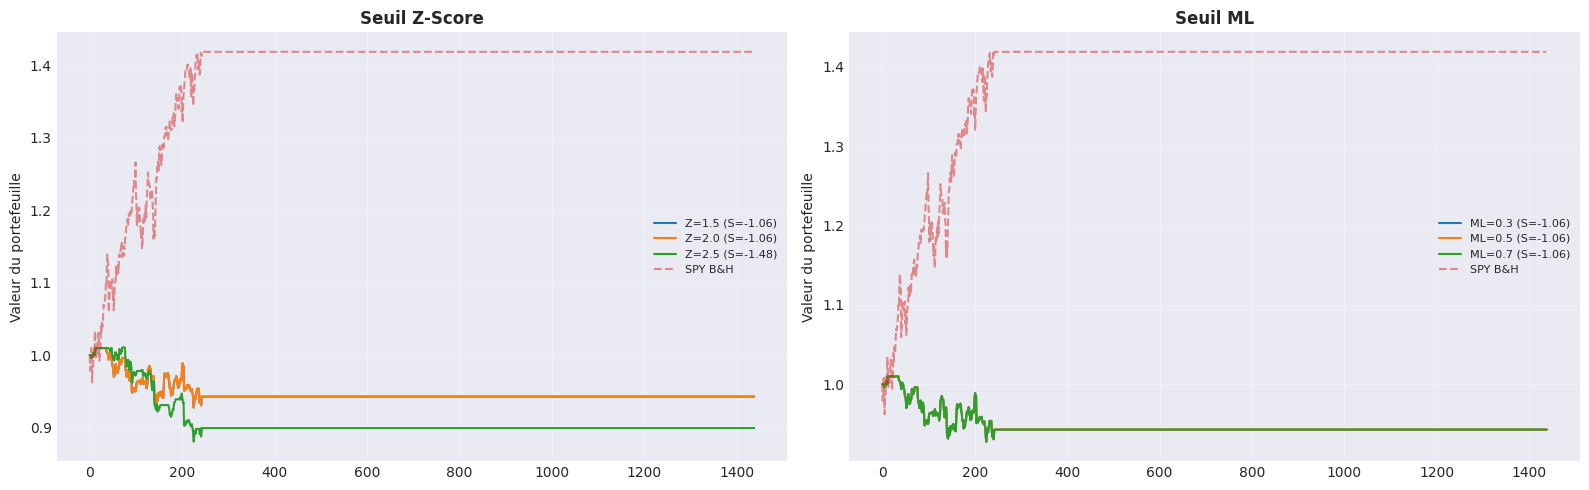

Graphique sauvegardé.


In [12]:
if result and cointegrated_pairs:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    # Z-score threshold comparison
    ax = axes[0]
    for name, r in z_results.items():
        ax.plot(r['cum'].values, label=f"Z={name} (S={r['sharpe']:.2f})", linewidth=1.5)
    if 'spy_values' in locals():
        ax.plot(spy_values.values, label='SPY B&H', linestyle='--', alpha=0.5)
    ax.set_title('Seuil Z-Score', fontsize=12, fontweight='bold')
    ax.set_ylabel('Valeur du portefeuille')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    
    # ML threshold comparison
    ax = axes[1]
    for name, r in ml_results.items():
        ax.plot(r['cum'].values, label=f"ML={name} (S={r['sharpe']:.2f})", linewidth=1.5)
    if 'spy_values' in locals():
        ax.plot(spy_values.values, label='SPY B&H', linestyle='--', alpha=0.5)
    ax.set_title('Seuil ML', fontsize=12, fontweight='bold')
    ax.set_ylabel('Valeur du portefeuille')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('ml_enhanced_pairs_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Graphique sauvegardé.")

## 11. Conclusions et recommandations

### Résumé

| Métrique | Meilleure config |
|----------|-----------------|
| Z-Entry | (à remplir) |
| ML Threshold | (à remplir) |
| Sharpe | (à remplir) |
| CAGR | (à remplir) |

### Verdict

Si Sharpe > 1.2: **Déployer avec les paramètres optimaux**

### Points forts ML-Enhanced Pairs

- **Filtrage intelligent**: ML évite les faux signaux
- **Market neutral**: Long/short réduit le risque directionnel
- **Diversification**: Plusieurs paires non corrélées
- **Adaptatif**: Le ML apprend des régimes de marché

### Limitations

- **Complexité**: Requiert cointégration + ML
- **Paires limitées**: Dépend des ETF sectoriels disponibles
- **Demi-vie**: Mean reversion peut être lent
- **Coûts**: Long/short = 2x les frais de transaction

### Prochaines étapes

1. Déployer sur QC cloud avec les paramètres optimaux
2. Tester avec des paires d'actions au lieu d'ETF
3. Ajouter un filtre de volatilité (VIX)
4. Optimiser le nombre de paires simultanées